In [1]:
# add packages/dependencies
using ImagePhantoms
using ImageGeoms: ImageGeom
using Plots
using MIRTjim
using NFFT
using LinearMapsAA
using Random
using LaTeXStrings
using Statistics

include("overlayview.jl")
include("fmri.jl")
include("solv.jl")

subspace_iteration (generic function with 1 method)

In [2]:
# set parameters
N = 100; # image size (NxN)
fov = 200; # FOV (mm)
tr = 62.5; # spoke TR (ms, matches looping star)
t_act = 20; # task on time (s)
act_lvl = 0.1; # activation level (fractional signal change)
σ_ε = 0.01; # noise std dev
nspokes = 4800; # total number of spokes
stride = 16; # sliding window stride (# spokes)
a_min = 32; # minimum aperature (# spokes)
ω_min = 0; # k-space radius for minimum aperature (rad)
a_max = 64; # maximum aperature (# spokes)
ω_max = pi; # k-space radius for maximum aperature (rad)
p = 1; # aperature function power parameter

In [3]:
# determine time points
M = 2 * N * nspokes; # total number of k-space samples
nframes = Int((nspokes - a_max) ÷ stride + 1); # number of frames
τ = [((f-1)*stride + a_max/2) * tr * 1e-3 for f in 1:nframes]; # nominal time points (where each image frame is sampled, s)
Δt = tr * 1e-3 / (2*N); # time between k-space samples (s)

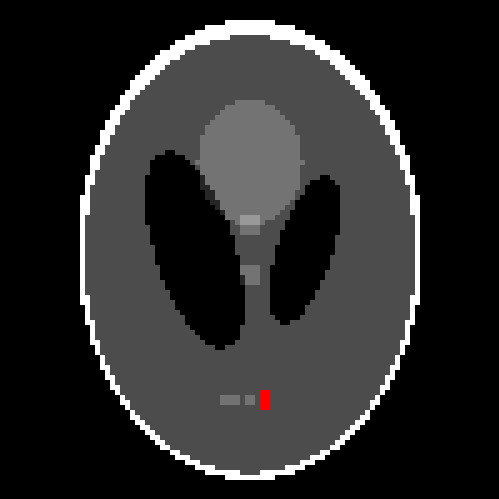

In [4]:
# create phantom
ig = ImageGeom(dims=(N, N), deltas=(fov/N, fov/N))
objects = shepp_logan(SheppLoganToft(); fovs=(fov, fov))
image = phantom(axes(ig)..., objects[1:9])
act_mask = phantom(axes(ig)..., objects[10:10]) .> 0

ov1 = ovLayer(image, (0,1));
ov2 = ovLayer(act_mask, (0,1));
ov = ovshow([ov1,ov2]);
cm1 = cgrad([:black, :white, :white, :red])
jim(axes(ig)..., ov["img_all"], color=cm1, axis=false, colorbar=false, margin=-20Plots.mm,
size=(500,500))

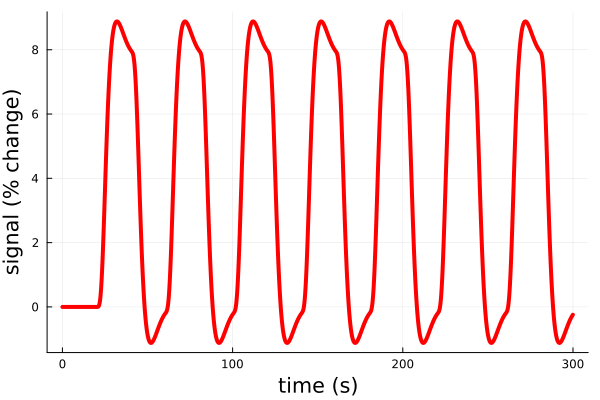

In [5]:
# create the task waveform
task = reshape(fmri_act(tr*1e-3 * (0:(nspokes-1)), t_act, t_act, 0), :, nspokes);
plot(tr*1e-3 * (0:(nspokes-1)), act_lvl*100 * task[:], xlabel="time (s)", ylabel="signal (% change)", 
    xlabelfontsize = 14,
    ylabelfontsize = 14,
    label=false, lw = 4, color=:red)

┌ Info: Saved animation to /tmp/jl_IlMPAVE1oZ.gif
└ @ Plots /home/djfrey/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/tmp/jl_IlMPAVE1oZ.gif")
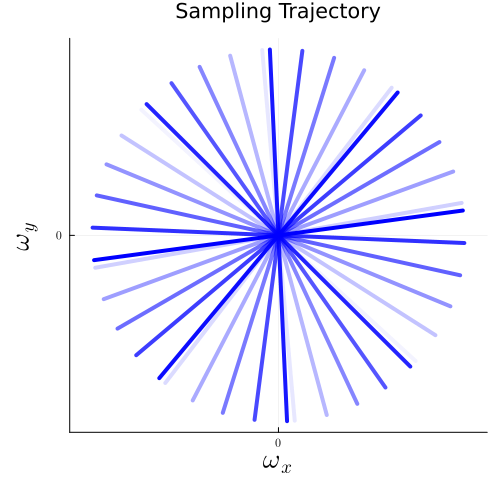

In [6]:
# create sampling trajectory and simulate k-space data
φ = pi*(3-sqrt(5))  # golden angle in radians
ktraj_raw = Array{Float32}(undef, 2*N, nspokes, 2)
for s in 1:nspokes
    ktraj_raw[:,s,:] = range(-N/fov/2, N/fov/2, 2 * N) .* [cos(s * φ), sin(s * φ)]'
end

# plot sampling trajectory
nspokes_show = 20
@gif for i in 1:2:100
    plt = plot(fov / N * 2 * ktraj_raw[:, (i+nspokes_show), 1], fov / N * 2 * ktraj_raw[:, (i+nspokes_show), 2],
        label=nothing,
        xlabel=L"\omega_x", ylabel=L"\omega_y", xlabelfontsize=18, ylabelfontsize=18,
        xticks=([-pi, 0, pi], [L"-\pi", L"0", L"\pi"]),
        yticks=([-pi, 0, pi], [L"-\pi", L"0", L"\pi"]),
        lw=4,
        aspect_ratio=1,
        color=:blue,
        size=(500, 500),
        title="Sampling Trajectory")
    for j in (i+nspokes_show-1:-1:1)
        plot!(plt,
            fov / N * 2 * ktraj_raw[:, j, 1], fov / N * 2 * ktraj_raw[:, j, 2],
            lw = 4,
            color=:blue,
            alpha=j/(i+nspokes_show),
            label=nothing)
    end
end

In [7]:
# simulate the k-space data using the analytical Fourier transform of the phantom
kdata_raw = Array{ComplexF32}(undef, 2 * N, nspokes);
spec_bkg = spectrum(objects[1:9]); spec_act = spectrum(objects[10]);
for s in 1:nspokes
    kdata_raw[:,s] = spec_bkg.(ktraj_raw[:, s, 1], ktraj_raw[:, s, 2]); # background component
    kdata_raw[:,s] .+= act_lvl * task[:,s] .* spec_act.(ktraj_raw[:, s, 1], ktraj_raw[:, s, 2]) # activation component
end

# add complex Gaussian noise
Random.seed!(0) # for reproducibility
kdata_raw .+= σ_ε^2 / sqrt(2) * (randn(ComplexF32, size(kdata_raw)) .+ im * randn(ComplexF32, size(kdata_raw)));

In [8]:
# create aperature function (# spokes as a function of k-space radius)
a = ω -> begin
    if ω <= ω_min
        return a_min
    elseif ω >= ω_max
        return a_max
    else
        return a_min + (a_max - a_min) * (ω - ω_min)^p / (ω_max - ω_min)^p
    end
end

# create the index sample sets
ω0 = 2 * pi * fov / N * vec(sqrt.(ktraj_raw[:, 1 : a_max, 1].^2 .+ ktraj_raw[:, 1 : a_max, 2].^2)) # k-space radii for max aperature samples
eM0 = findall( abs.(Δt*(1:2*N*a_max) .- τ[1]) .<= Δt * N * a.(ω0) ) .- floor(Int, τ[1]/Δt) # unshifted index set
Mtilde = length(eM0); # bin size (in number of k-space samples)

# set up (frame dependent) binning operator
B_f = f -> LinearMapAA(
    x -> x[floor(Int, τ[1]/Δt) .+ eM0],
    y -> begin
        x = zeros(ComplexF32, M)
        x[floor(Int, τ[f]/Δt) .+ eM0] = y
        return x
    end,
    (Mtilde,M),
    idim = (M,),
    odim = (Mtilde,)
)

# set up big binning operator
B = LinearMapAA(
    x -> hcat([B_f(f) * x for f in 1:nframes]...),
    y -> begin
        x = zeros(ComplexF32, M)
        for f in 1:nframes
            x .+= B_f(f)' * y[:,f]
        end
        return x
    end,
    (nframes*Mtilde,M),
    idim = (M,),
    odim = (Mtilde,nframes)
)

# set up pseudo-inverse binning operator
countvec = real(B' * ones(Mtilde,nframes)) # counts the number of bins each sample is represented in (0 norm of each column of B)
Binv = LinearMapAA(
    x -> begin
        y = B' * x
        y[countvec .> 0] ./= countvec[countvec .> 0] # only divide where countvec > 0 to avoid NaNs
        return y
    end,
    y -> begin
        y[countvec .> 0] ./= countvec[countvec .> 0] # only divide where countvec > 0 to avoid NaNs
        x = B * y
    end,
    (M,nframes*Mtilde),
    idim = (Mtilde,nframes),
    odim = (M,)
);

In [9]:
# set up the frame-wise NUFFT acquisition model
nuffts = Vector{Any}(undef, nframes)
ktraj = reshape(B * reshape(ktraj_raw, :, 2), :, nframes, 2)
for f in 1:nframes
    nuffts[f] = plan_nfft(fov/N * ktraj[:,f,:]', (N, N); m=4, σ=2.0) # create NFFT plan
end
A = LinearMapAA(
    x -> begin
        y = zeros(eltype(x),(Mtilde,nframes));
        for f in 1:nframes
            y[:,f] = nuffts[f] * x[:,:,f]
        end
        return y
    end,
    y -> begin
        x = zeros(eltype(y),(N,N,nframes));
        for f in 1:nframes
            x[:,:,f] = adjoint(nuffts[f]) * y[:,f]
        end
        return x
    end,
    (Mtilde*nframes, N^2*nframes), 
    idim=(N,N,nframes),
    odim=(Mtilde,nframes)
);

In [21]:
# set up the physiological noise covariance matrix
σ_ζ = 0.5; # physiological noise std dev
Σ_ζ = LinearMapAA(
    x -> range(-σ_ζ^2, σ_ζ^2, length=Mtilde) .* x,
    y -> range(-σ_ζ^2, σ_ζ^2, length=Mtilde) .* y,
    (Mtilde*nframes,Mtilde*nframes),
    idim = (Mtilde,nframes),
    odim = (Mtilde,nframes)
)

# set up the covariance matrix
Σ = LinearMapAA(
    x -> σ_ε^2 * B * (B' * x) .+ (Σ_ζ * x),
    y -> σ_ε^2 * B * (B' * y) .+ (Σ_ζ * y),
    (nframes*Mtilde,nframes*Mtilde),
    idim = (Mtilde,nframes),
    odim = (Mtilde,nframes)
)

# set up the inverse covariance matrix (solved with CG)
Σ_inv = LinearMapAA(
    x -> cg(Σ, zeros(eltype(x), size(x)), x, niter=10),
    y -> cg(Σ, zeros(eltype(y), size(y)), y, niter=10),
    (nframes*Mtilde,nframes*Mtilde),
    idim = (Mtilde,nframes),
    odim = (Mtilde,nframes)
)

LinearMapAO: 2857734 × 2857734 odim=(9622, 297) idim=(9622, 297) T=Float32 Do=2 Di=2
map = 2857734×2857734 LinearMaps.FunctionMap{Float32,false}(#6, #8; issymmetric=false, ishermitian=false, isposdef=false)


In [ ]:
# operator multiplication
opmult = (A1,A2) -> LinearMapAA(
    x -> A1 * (A2 * x),
    y -> A2' * (A1' * y),
    (prod(A1._odim), prod(A2._idim)),
    idim = A2._idim,
    odim = A1._odim
)

# set up reconstructions
x0 = zeros(ComplexF32, N, N, nframes); # initial guess
AHBb = A' * (B * kdata_raw[:]); # precompute A' * B * b
AHΣinvBb = A' * (Σ_inv * (B * kdata_raw[:])); # precompute A' * Σ_inv * Bb
AHΣinvA = opmult(A', opmult(Σ_inv, A)); # precompute A' * Σ_inv * A
AHA = opmult(A', A); # precompute A' * A

#62 (generic function with 1 method)

In [ ]:
x_nominal = cg(AHA, x0, AHBb; verbose=true) # run the recon with the "nominal" model
x_binned = cg(AHΣinvA, x0, ΣinvAHBb; verbose=true) # run the recon with the "binned" model

cg initialization:  residual norm =  5.707e+08,  time =   67.049s
cg iteration    1:  residual norm =  7.442e+07,  time =   75.841s
cg iteration    2:  residual norm =  3.487e+07,  time =   68.409s
cg iteration    3:  residual norm =  2.361e+07,  time =   68.310s
cg iteration    4:  residual norm =  1.420e+07,  time =   65.915s
cg iteration    5:  residual norm =  7.729e+06,  time =   69.037s
cg iteration    6:  residual norm =  1.037e+07,  time =   65.650s
cg iteration    7:  residual norm =  5.717e+06,  time =   64.912s
cg iteration    8:  residual norm =  3.630e+06,  time =   65.295s
cg iteration    9:  residual norm =  2.829e+06,  time =   60.803s
cg iteration   10:  residual norm =  1.932e+06,  time =   63.380s
cg iteration   11:  residual norm =  1.496e+06,  time =   60.272s
cg iteration   12:  residual norm =  2.318e+06,  time =   63.769s
cg iteration   13:  residual norm =  1.277e+06,  time =   63.186s
cg iteration   14:  residual norm =  9.234e+05,  time =   66.474s
cg iterati

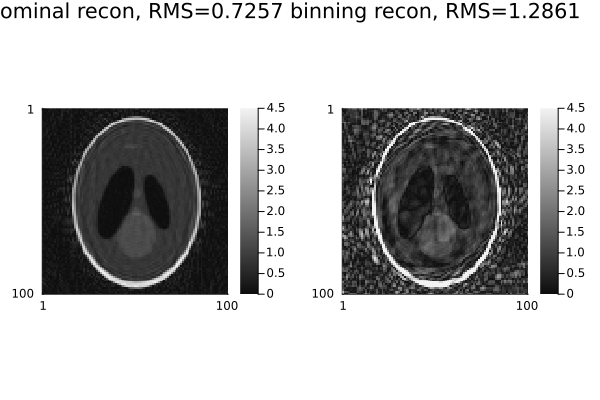

In [171]:

rms = x -> sqrt(mean(abs2.(x[:,:,1] - image)))
p1 = jim(x_nominal[:,:,2], title="nominal recon, RMS=$(round(rms(x_nominal), digits=4))", clim=(0,4.5))
p2 = jim(x_binned[:,:,2], title="binning recon, RMS=$(round(rms(x_binned), digits=4))", clim=(0,4.5))
plot(p1,p2)

In [172]:
# calculate the t-score map
GLM = fmri_act(τ, t_act, t_act, 0) .^ [0, 1]'; # [baseline, task]
(tscore_1, ~) = fmri_tscore(GLM, x_nominal);
(tscore_2, ~) = fmri_tscore(GLM, x_binned);

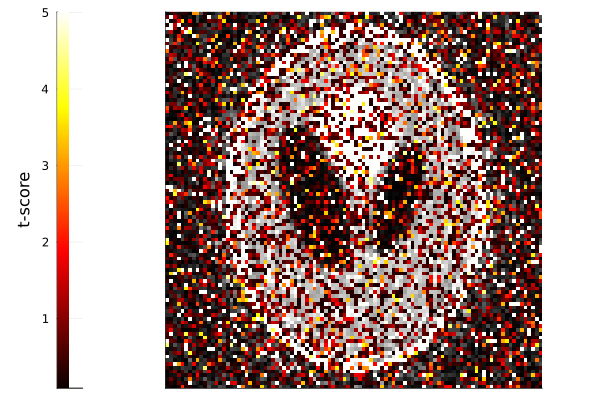

In [173]:
# show the overlaid t-score
tscore_range = (0.1, 5);
ov0 = ovLayer(abs.(x_nominal[:, :, 1]), (0, 1));
ov1 = ovLayer(tscore_1[:, :, 2], tscore_range; color=:hot);
O = ovshow([ov0, ov1])
povl = jim(axes(ig)..., O["img_all"]; color=O["color_all"], clim=O["clim_all"],
    colorbar=false, xticks=false, yticks=false)
pcb = heatmap(ones((1,)), range(tscore_range[1], tscore_range[2], 256),
    reshape(range(tscore_range[1], tscore_range[2], 256), (256, 1)),
    xticks=false, color=:hot, colorbar=false,
    xlim=(1, 1), ylabel="t-score",
    aspect_ratio=3)
pact = plot(pcb, povl, background_color = :transparent, layout=@layout [a{0.1w} b{0.9w}])

In [174]:
# calculate ROC curve and AUC
nthresh = 100; # number of t-score thresholds to test
tscore_max = max(maximum(tscore[:, :, 2][act_mask]), maximum(tscore[:, :, 2][.!act_mask]))
tscore_thresh = range(tscore_max,0,nthresh); # t-score thresholds to test
TPR = Vector{Float32}(undef,nthresh);
FPR = Vector{Float32}(undef,nthresh);
for i in 1:nthresh
    ntp = count(tscore[:, :, 2][act_mask] .>= tscore_thresh[i]) # number of true positives
    nfn = count(tscore[:, :, 2][act_mask] .< tscore_thresh[i]) # number of false negatives
    nfp = count(tscore[:, :, 2][.!act_mask] .>= tscore_thresh[i]) # number of false positives
    ntn = count(tscore[:, :, 2][.!act_mask] .< tscore_thresh[i]) # number of true negatives
    TPR[i] = ntp / (ntp + nfn); # true positive rate
    FPR[i] = nfp / (nfp + ntn); # false positive rate
end
# append (0,0) and (1,1) to each axis
FPR_full = vcat(0.0, FPR, 1.0)
TPR_full = vcat(0.0, TPR, 1.0)

# compute AUC using trapezoidal rule
AUC = sum(0.5 * (TPR_full[2:end] + TPR_full[1:end-1]) .* (FPR_full[2:end] - FPR_full[1:end-1]));

# get the mean signal from the roi
mean_signal_roi = 1/count(act_mask) * vcat([sum(abs.(x_star[:,:,i])[act_mask]) for i in 1:nframes]...);

UndefVarError: UndefVarError: `tscore` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [175]:
# plot ROC curve
proc = plot(FPR_full, TPR_full,
    xlabel="FPR", ylabel="TPR",
    background_color = :transparent,
    fillrange=0, fillcolor=:lightblue,
    label=false);
annotate!(proc, FPR[round(Int, nthresh * 0.75)], TPR[round(Int, nthresh / 2)],
    text("AUC = $(round(AUC, digits=10))", :left, :black))
savefig(proc, "~/Desktop/roc_curve.png")

UndefVarError: UndefVarError: `FPR_full` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [176]:
# show the overlaid t-score
tscore_range = (0.1, 5);
ov0 = ovLayer(abs.(x_star[:, :, 1]), (0, 1));
ov1 = ovLayer(tscore[:, :, 2], tscore_range; color=:hot);
O = ovshow([ov0, ov1])
povl = jim(axes(ig)..., O["img_all"]; color=O["color_all"], clim=O["clim_all"],
    colorbar=false, xticks=false, yticks=false)
pcb = heatmap(ones((1,)), range(tscore_range[1], tscore_range[2], 256),
    reshape(range(tscore_range[1], tscore_range[2], 256), (256, 1)),
    xticks=false, color=:hot, colorbar=false,
    xlim=(1, 1), ylabel="t-score",
    aspect_ratio=3)
pact = plot(pcb, povl, background_color = :transparent, layout=@layout [a{0.1w} b{0.9w}])

UndefVarError: UndefVarError: `x_star` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [177]:
show_plots = false # set to true if you want to see the plots :)

# show the windowing functions
ncycles_show = 10
kr_show = range(0, N / fov / 2, 100)
t_show = range(0, min(t[end], t_act*ncycles_show), 1000)
normalize = x -> (x .- minimum(x)) ./ (maximum(x) - minimum(x))

# display the task waveform and mean signal in roi
psig = plot(t_show, normalize(fmri_act(t_show,t_act,t_act,0)), label="task",
    xlabel="time (s)", ylabel="signal",
    ylim=(0,1), yticks=false
)
plot!(psig, t_hat, normalize(mean_signal_roi),
    label="mean signal (roi)",
    xlim=(0, t_act*ncycles_show)
)

# show the windowing functions
t_sub = range(-tr*1e-3, (a_max + stride + 1)*tr*1e-3, 100)
pwin = plot(
    heatmap(t_sub, kr_show, window.(t_hat[1] / (tr * 1e-3), t_sub' / (tr * 1e-3), kr_show),
        xticks=false, xlabel=nothing, title="frame 1 windowing function"), # 1st frame
    heatmap(t_sub, kr_show, window.(t_hat[2] / (tr * 1e-3), t_sub' / (tr * 1e-3), kr_show),
        xlabel="time(s)", title="frame 2 windowing function"), # 2nd frame
    layout = (2,1),
    ylim=(0, N / fov / 2),
    color=window_color, colorbar=false,
    ylabel=L"|k|",
    yticks=((0, N / fov / 2), ("0", L"k_\mathrm{max}")))

# show the overlaid t-score
tscore_range = (0.1, 5);
ov0 = ovLayer(abs.(x_star[:, :, 1]), (0, 1));
ov1 = ovLayer(tscore[:, :, 2], tscore_range; color=:hot);
O = ovshow([ov0, ov1])
povl = jim(axes(ig)..., O["img_all"]; color=O["color_all"], clim=O["clim_all"],
    colorbar=false, xticks=false, yticks=false,
    title="Activation map")
pcb = heatmap(ones((1,)), range(tscore_range[1], tscore_range[2], 256),
    reshape(range(tscore_range[1], tscore_range[2], 256), (256, 1)),
    xticks=false, color=:hot, colorbar=false,
    xlim=(1, 1), ylabel="t-score",
    aspect_ratio=3)
pact = plot(pcb, povl,  layout=@layout [a{0.1w} b{0.9w}])

# plot ROC curve
proc = plot(FPR_full, TPR_full,
    xlabel="FPR", ylabel="TPR",
    title="ROC Curve",
    fillrange=0, fillcolor=:lightblue,
    label=false);
annotate!(proc, FPR[round(Int, nthresh * 0.75)], TPR[round(Int, nthresh / 2)],
    text("AUC = $(round(AUC, digits=10))", :left, :black))

if show_plots
    # save a big ol figure with all the results
    @gif for f in 1:min(nframes,50)
        # show the reconned frame
        prec = jim(axes(ig)..., x_star[:, :, f], clim=(0, 0.7), xticks=false, yticks=false, colorbar=false,
            title="frame-wise recon")
        annotate!(prec, axes(ig)[1][1], axes(ig)[2][1], ("frame $f", 12, :white, :left, :bottom), bg=:black)

        # plot all
        p_sub2 = plot(pwin, prec, layout=@layout [a{0.5w} b{0.5w}])
        p_sub3 = plot(proc, pact, layout=@layout [a{0.4w} b{0.6w}])
        plot(
            psig,
            p_sub2,
            p_sub3,
            size=(900, 1200),
            layout=@layout [a{0.2h}; b{0.4h}; c{0.4h}]
        );
    end
end

UndefVarError: UndefVarError: `mean_signal_roi` not defined in `Main`
Suggestion: check for spelling errors or missing imports.